# Standard Neural Network for preference learning

In [127]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Resolve project root whether notebook runs from workspace root or notebooks/
cwd = Path.cwd()
project_root = cwd if (cwd / "data").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.metrics import evaluate_model

## Load data
We use `hospital_overall_rating` as a binary target variable:
- `0` for bad hospital (`rating < 4`)
- `1` for good hospital (`rating >= 4`)

In [128]:
data_path = project_root / "data" / "hospital_data.csv"
df = pd.read_csv(data_path)

meta_cols = ["facility_id", "facility_name"]
cost_cols = [
    "mort_ami",
    "comp_hip_knee",
    "readmission_hf",
    "spending",
    "count_of_readm_measures_worse",
]
gain_cols = ["count_of_safety_measures_better"]
feature_cols = cost_cols + gain_cols

model_df = df.copy()
model_df["target"] = (model_df["hospital_overall_rating"] >= 4).astype(int)

X = model_df[feature_cols].values
y = model_df["target"].values

print("Rows:", len(model_df))
print("Features:", len(feature_cols))
print("Class distribution:")
print(pd.Series(y).value_counts(normalize=True).rename("share").round(4))

Rows: 500
Features: 6
Class distribution:
0    0.602
1    0.398
Name: share, dtype: float64


## Data splitting and standard scaling

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (400, 6)
Test shape: (100, 6)


## Batch Loaders

In [130]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1),
)
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32).unsqueeze(1),
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
train_eval_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train batches:", len(train_loader))
print("Train eval batches:", len(train_eval_loader))
print("Test batches:", len(test_loader))

Train batches: 25
Train eval batches: 25
Test batches: 7


## MLP (6 -> 16 -> 8 -> 1)

In [131]:
class StandardNN(nn.Module):
    def __init__(self, input_size: int = 6):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 8)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.layer2 = nn.Linear(8, 4)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.output = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.output(x)
        x = self.sigmoid(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StandardNN(input_size=len(feature_cols)).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-3)

print(model)
print("Device:", device)

StandardNN(
  (layer1): Linear(in_features=6, out_features=8, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=8, out_features=4, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Device: cuda


## Train model

In [132]:
epochs = 50 # Only 50 because of the small dataset and to prevent overfitting (which is almost guaranteed here)
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_state = None

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss = running_val_loss / len(test_dataset)
    val_losses.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:3d}: train_loss={epoch_train_loss:.4f}, val_loss={epoch_val_loss:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print(f"Best validation loss: {best_val_loss:.4f}")

Epoch  10: train_loss=0.5591, val_loss=0.4496
Epoch  20: train_loss=0.5378, val_loss=0.4500
Epoch  30: train_loss=0.5282, val_loss=0.4524
Epoch  40: train_loss=0.5335, val_loss=0.4631
Epoch  50: train_loss=0.5283, val_loss=0.4737
Best validation loss: 0.4415


## Predict and evaluate

In [133]:
def predict_dataset(data_loader):
    model.eval()
    probs_list = []
    with torch.no_grad():
        for X_batch, _ in data_loader:
            X_batch = X_batch.to(device)
            probs = model(X_batch)
            probs_list.append(probs.detach().cpu().numpy())
    probs = np.concatenate(probs_list, axis=0).reshape(-1)
    preds = (probs >= 0.5).astype(int)
    return preds, probs

train_preds, train_probs = predict_dataset(train_eval_loader)
test_preds, test_probs = predict_dataset(test_loader)

train_metrics = evaluate_model(y_train, train_preds, train_probs)
test_metrics = evaluate_model(y_test, test_preds, test_probs)

print("Train metrics (4 decimals):")
for name, value in train_metrics.items():
    print(f"{name}: {value:.4f}")

print("\nTest metrics (4 decimals):")
for name, value in test_metrics.items():
    print(f"{name}: {value:.4f}")

Train metrics (4 decimals):
accuracy: 0.7375
f1: 0.6624
auc: 0.8104

Test metrics (4 decimals):
accuracy: 0.8100
f1: 0.7654
auc: 0.8883


## Training curve

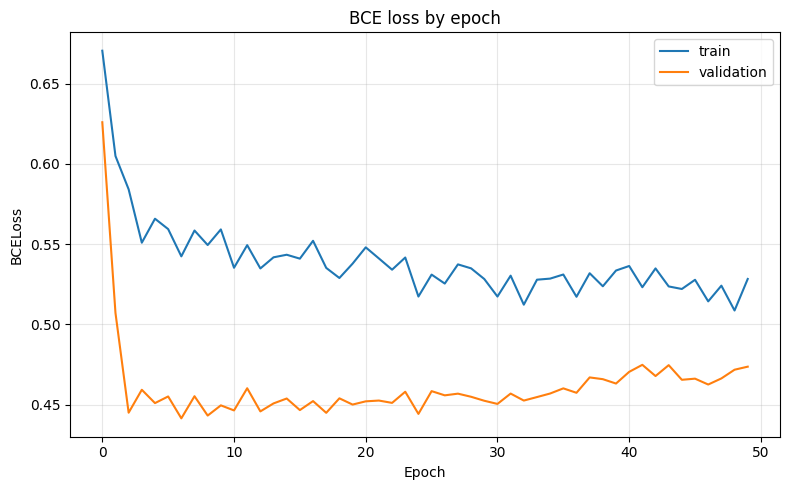

In [134]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label="train")
ax.plot(val_losses, label="validation")
ax.set_title("BCE loss by epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCELoss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

## Save model

In [135]:
models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "standard_nn_hospital.pt"
metadata = {
    "feature_cols": feature_cols,
    "cost_cols": cost_cols,
    "gain_cols": gain_cols,
    "target_rule": "hospital_overall_rating >= 4 -> 1 else 0",
    "architecture": "6->16->8->1 (ReLU, ReLU, Sigmoid)",
    "loss": "BCELoss",
    "optimizer": "AdamW",
    "learning_rate": 0.01,
    "batch_size": 16,
    "epochs": epochs,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "test_metrics": test_metrics,
}

torch.save({"model_state_dict": model.state_dict(), "metadata": metadata}, model_path)
print(f"Saved model to: {model_path}")

Saved model to: /home/marek/put/DA/mcda/models/standard_nn_hospital.pt
